# BBPSSW distillation in simyuj

This notebook runs one BBPSSW entanglement-distillation round with three nodes: a central source, Alice, and Bob. The source emits two Bell pairs, Alice and Bob store one source/control pair plus one sacrificial/target pair, the endpoint agents run bilateral CNOTs and target measurements, and Alice records the final fidelity of the kept source pair.


## Protocol plan

- Pair 1 is the source/control pair and is stored in memory position `0`.
- Pair 2 is the sacrificial/target pair and is stored in memory position `1`.
- Alice and Bob exchange readiness after both local positions are occupied.
- Each endpoint applies `CNOT(control=source, target=sacrificial)` locally.
- Each endpoint measures the sacrificial position in the Z basis and exchanges the target measurement bit.
- Matching bits keep the source pair; different bits reject and discard it.


In [195]:
from __future__ import annotations

import json
from dataclasses import dataclass, field
from typing import Any

from simyuj.components.channels import (
    ACTION_TRANSMIT_CLASSICAL,
    ACTION_TRANSMIT_QUANTUM,
    ClassicalChannel,
    QuantumChannel,
)
from simyuj.components.memories import (
    MEMORY_ABSORB,
    MemoryAbsorbReport,
    MemoryDiscardReport,
    MemoryMeasurementReport,
    MemoryOperatorReport,
    QuantumMemory,
    memory_subsystem_id,
)
from simyuj.components.sources import EntangledPairSource, SourcePreparationReport
from simyuj.control import AGENT_MESSAGE, AGENT_REPORT, AgentContext, NodeAgent, SessionRuntime
from simyuj.engine import Timeline
from simyuj.network import Network, Node
from simyuj.primitives.messages.transport import ClassicalMessage
from simyuj.primitives.units import seconds_to_ticks, ticks_to_seconds
from simyuj.qstate import StateSampler
from simyuj.qstate.noise import DepolarizingNoise, depolarizing
from simyuj.qstate.ops import CNOT
from simyuj.qstate.state import bell_diag_to_density, bell_fidelity, werner


## Configuration

The baseline uses real propagation distances with zero attenuation and no channel or memory noise. Later experiments can change the fidelity, attenuation, channel depolarization, or memory depolarization fields without changing the protocol wiring.


In [196]:
@dataclass(frozen=True, slots=True)
class BBPSSWConfig:
    master_seed: int = 2026
    source_to_alice_km: float = 10.0
    source_to_bob_km: float = 10.0
    fiber_speed_m_per_s: float = 2.0e8

    source_frequency_hz: float = 1.0e6
    source_pair_fidelity: float = 1.0
    target_bell_label: str = "phi+"

    attenuation_db_per_km: float = 0.0
    fixed_insertion_loss_db: float = 0.0
    channel_depolarizing_probability: float = 0.0
    channel_timing_jitter_stddev_s: float = 0.0

    memory_depolar_rate: float = 0.0
    cnot_delay_s: float = 0.0
    measure_delay_s: float = 0.0
    storage_lifetime_s: float | None = None


config = BBPSSWConfig()
config


BBPSSWConfig(master_seed=2026, source_to_alice_km=10.0, source_to_bob_km=10.0, fiber_speed_m_per_s=200000000.0, source_frequency_hz=1000000.0, source_pair_fidelity=1.0, target_bell_label='phi+', attenuation_db_per_km=0.0, fixed_insertion_loss_db=0.0, channel_depolarizing_probability=0.0, channel_timing_jitter_stddev_s=0.0, memory_depolar_rate=0.0, cnot_delay_s=0.0, measure_delay_s=0.0, storage_lifetime_s=None)

In [197]:
SOURCE_PAIR_INDEX = 1
TARGET_PAIR_INDEX = 2


def meta_get(meta: tuple[tuple[str, object], ...], key: str, default=None):
    value = default
    for item_key, item_value in meta:
        if item_key == key:
            value = item_value
    return value


def pair_index_from_signal_id(signal_id: object) -> int:
    parts = str(signal_id).split(":")
    if len(parts) < 4 or parts[1] != "pair":
        raise ValueError(f"unexpected entangled-pair signal id: {signal_id!r}")
    return int(parts[2])


def json_body(message) -> dict[str, Any]:
    body = message.message.body
    if isinstance(body, bytes):
        body = body.decode("utf-8")
    decoded = json.loads(body)
    if not isinstance(decoded, dict):
        raise TypeError("BBPSSW messages must carry a JSON object")
    return decoded


def measurement_bit(report: MemoryMeasurementReport) -> int:
    if report.detection_report is None or not report.detection_report.success:
        raise RuntimeError("target measurement did not produce a usable bit")
    outcome = report.detection_report.outcome
    if outcome in ("0", 0):
        return 0
    if outcome in ("1", 1):
        return 1
    raise ValueError(f"unexpected target measurement outcome: {outcome!r}")


def source_sampler_for(config: BBPSSWConfig) -> StateSampler:
    if config.source_pair_fidelity == 1.0:
        return StateSampler(
            states=(config.target_bell_label,),
            probabilities=(1.0,),
            rep="ket",
            labels=(config.target_bell_label,),
        )

    state = bell_diag_to_density(
        werner(config.source_pair_fidelity, label=config.target_bell_label)
    )
    return StateSampler(
        states=(state,),
        probabilities=(1.0,),
        rep="density",
        labels=(f"werner_{config.target_bell_label}_F={config.source_pair_fidelity}",),
    )


def channel_noise_models(config: BBPSSWConfig):
    if config.channel_depolarizing_probability == 0.0:
        return ()
    return (depolarizing(config.channel_depolarizing_probability),)


def memory_noise_model(config: BBPSSWConfig):
    if config.memory_depolar_rate == 0.0:
        return None
    return DepolarizingNoise(config.memory_depolar_rate)


def optional_seconds_to_ticks(value: float | None) -> int | None:
    if value is None:
        return None
    return seconds_to_ticks(value)


## Agents

The source agent only starts the pair source and records source reports. Alice and Bob are report-driven endpoint agents: they wait for memory absorbs, exchange readiness, request local memory operations, exchange target measurement bits, and then keep or reject the source pair.


In [198]:
@dataclass(slots=True)
class BBPSSWSourceAgent(NodeAgent):
    source_name: str = "source"
    source_reports: list[SourcePreparationReport] = field(default_factory=list)
    trace: list[dict[str, object]] = field(default_factory=list)

    def on_start(self, start, ctx: AgentContext) -> None:
        del start
        source = ctx.devices.get(self.source_name)
        if not isinstance(source, EntangledPairSource):
            raise TypeError("source device must be EntangledPairSource")
        source.schedule_start(ctx.timeline)
        self.trace.append(
            {"time": ctx.timeline.current_time, "event": "source_started"}
        )

    def on_report(self, report: object, ctx: AgentContext) -> None:
        del ctx
        if isinstance(report, SourcePreparationReport):
            self.source_reports.append(report)
            return
        raise TypeError(f"source agent received unsupported report: {type(report)!r}")


In [199]:
@dataclass(slots=True)
class BBPSSWEndpointAgent(NodeAgent):
    memory_name: str = "memory"
    peer_id: str = ""
    out_port: str = ""
    coordinator: bool = False

    local_memory_id: str | None = None
    peer_memory_id: str | None = None
    source_position: int | None = None
    target_position: int | None = None
    peer_source_position: int | None = None
    peer_target_position: int | None = None

    pair_index_by_position: dict[int, int] = field(default_factory=dict)
    absorb_reports: list[MemoryAbsorbReport] = field(default_factory=list)
    measurement_reports: list[MemoryMeasurementReport] = field(default_factory=list)

    ready_sent: bool = False
    peer_ready: bool = False
    cnot_requested: bool = False
    cnot_complete: bool = False
    target_measure_requested: bool = False
    target_bit: int | None = None
    peer_target_bit: int | None = None
    keep: bool | None = None
    final_fidelity: float | None = None
    final_state_ref: int | None = None
    final_layout: tuple[str, ...] = ()
    trace: list[dict[str, object]] = field(default_factory=list)

    def on_report(self, report: object, ctx: AgentContext) -> None:
        if isinstance(report, MemoryAbsorbReport):
            self._handle_absorb_report(report, ctx)
            return
        if isinstance(report, MemoryOperatorReport):
            self._handle_operator_report(report, ctx)
            return
        if isinstance(report, MemoryMeasurementReport):
            self._handle_measurement_report(report, ctx)
            return
        if isinstance(report, MemoryDiscardReport):
            self.trace.append(
                {
                    "time": ctx.timeline.current_time,
                    "event": "discard_report",
                    "position": report.position,
                    "success": report.success,
                    "reason": report.reason,
                }
            )
            return
        raise TypeError(f"{self.agent_id} received unsupported report: {type(report)!r}")

    def on_message(self, message, ctx: AgentContext) -> None:
        message_type = message.message.message_type
        if message_type == "bbpssw.ready":
            self._handle_ready_message(json_body(message), ctx)
            return
        if message_type == "bbpssw.target_result":
            self._handle_target_result_message(json_body(message), ctx)
            return
        raise ValueError(f"unsupported BBPSSW message: {message_type!r}")

    @property
    def locally_ready(self) -> bool:
        return self.source_position is not None and self.target_position is not None

    def _handle_absorb_report(self, report: MemoryAbsorbReport, ctx: AgentContext) -> None:
        self.absorb_reports.append(report)
        if not report.success:
            self.trace.append(
                {
                    "time": ctx.timeline.current_time,
                    "event": "absorb_failed",
                    "position": report.position,
                    "status": report.status,
                }
            )
            return

        pair_index = pair_index_from_signal_id(report.input_signal_id)
        self.pair_index_by_position[report.position] = pair_index
        if pair_index == SOURCE_PAIR_INDEX:
            self.source_position = report.position
        elif pair_index == TARGET_PAIR_INDEX:
            self.target_position = report.position
        else:
            raise ValueError(f"unexpected pair index for one BBPSSW round: {pair_index}")

        self.trace.append(
            {
                "time": ctx.timeline.current_time,
                "event": "absorbed",
                "position": report.position,
                "pair_index": pair_index,
                "signal_id": str(report.input_signal_id),
            }
        )
        self._maybe_send_ready(ctx)
        self._try_start_cnot(ctx)

    def _handle_operator_report(self, report: MemoryOperatorReport, ctx: AgentContext) -> None:
        stage = meta_get(report.meta, "stage")
        if stage != "bilateral_cnot":
            return
        if not report.success:
            raise RuntimeError(f"local CNOT failed for {self.agent_id}")
        if self.target_position is None:
            raise RuntimeError("target position is unknown")

        self.cnot_complete = True
        self.trace.append(
            {"time": ctx.timeline.current_time, "event": "cnot_complete"}
        )
        if not self.target_measure_requested:
            self.target_measure_requested = True
            ctx.memory.measure(
                self.memory_name,
                (self.target_position,),
                measurement="z",
                collapse=True,
                destructive=True,
                request_id=f"{self.agent_id}:measure_target:1",
                meta=(
                    ("protocol", "bbpssw"),
                    ("stage", "target_measurement"),
                    ("target_position", self.target_position),
                ),
            )
            self.trace.append(
                {"time": ctx.timeline.current_time, "event": "measure_target_requested"}
            )

    def _handle_measurement_report(self, report: MemoryMeasurementReport, ctx: AgentContext) -> None:
        stage = meta_get(report.meta, "stage")
        if stage != "target_measurement":
            return
        bit = measurement_bit(report)
        self.measurement_reports.append(report)
        self.target_bit = bit
        self.trace.append(
            {
                "time": ctx.timeline.current_time,
                "event": "target_measured",
                "bit": bit,
                "position": report.positions[0],
            }
        )
        self._send(
            ctx,
            "bbpssw.target_result",
            {
                "target_bit": bit,
                "target_position": report.positions[0],
                "memory_id": self.local_memory_id,
            },
        )
        self._try_decide(ctx)

    def _handle_ready_message(self, body: dict[str, Any], ctx: AgentContext) -> None:
        self.peer_ready = True
        self.peer_memory_id = str(body["memory_id"])
        self.peer_source_position = int(body["source_position"])
        self.peer_target_position = int(body["target_position"])
        self.trace.append(
            {
                "time": ctx.timeline.current_time,
                "event": "peer_ready",
                "peer_source_position": self.peer_source_position,
                "peer_target_position": self.peer_target_position,
            }
        )
        self._try_start_cnot(ctx)

    def _handle_target_result_message(self, body: dict[str, Any], ctx: AgentContext) -> None:
        self.peer_target_bit = int(body["target_bit"])
        self.trace.append(
            {
                "time": ctx.timeline.current_time,
                "event": "peer_target_result",
                "peer_target_bit": self.peer_target_bit,
            }
        )
        self._try_decide(ctx)

    def _maybe_send_ready(self, ctx: AgentContext) -> None:
        if not self.locally_ready or self.ready_sent:
            return
        memory = ctx.devices.memory(self.memory_name)
        self.local_memory_id = memory.memory_id
        self.ready_sent = True
        self._send(
            ctx,
            "bbpssw.ready",
            {
                "memory_id": self.local_memory_id,
                "source_position": self.source_position,
                "target_position": self.target_position,
                "pair_index_by_position": self.pair_index_by_position,
            },
        )
        self.trace.append(
            {"time": ctx.timeline.current_time, "event": "ready_sent"}
        )

    def _try_start_cnot(self, ctx: AgentContext) -> None:
        if not (self.locally_ready and self.peer_ready) or self.cnot_requested:
            return
        if self.source_position is None or self.target_position is None:
            raise RuntimeError("source and target positions must be known")
        self.cnot_requested = True
        ctx.memory.apply(
            self.memory_name,
            (self.source_position, self.target_position),
            CNOT,
            request_id=f"{self.agent_id}:bilateral_cnot:1",
            meta=(
                ("protocol", "bbpssw"),
                ("stage", "bilateral_cnot"),
                ("source_position", self.source_position),
                ("target_position", self.target_position),
            ),
        )
        self.trace.append(
            {
                "time": ctx.timeline.current_time,
                "event": "cnot_requested",
                "source_position": self.source_position,
                "target_position": self.target_position,
            }
        )

    def _try_decide(self, ctx: AgentContext) -> None:
        if self.keep is not None:
            return
        if self.target_bit is None or self.peer_target_bit is None:
            return
        self.keep = self.target_bit == self.peer_target_bit
        self.trace.append(
            {
                "time": ctx.timeline.current_time,
                "event": "decision",
                "keep": self.keep,
                "target_bit": self.target_bit,
                "peer_target_bit": self.peer_target_bit,
            }
        )
        if self.keep:
            if self.coordinator:
                self._record_final_fidelity(ctx)
            return

        if self.source_position is None:
            raise RuntimeError("cannot reject without a source position")
        ctx.memory.discard(
            self.memory_name,
            self.source_position,
            reason="bbpssw_rejected",
            request_id=f"{self.agent_id}:discard_rejected_source:1",
            meta=(("protocol", "bbpssw"), ("stage", "reject_source_pair")),
        )

    def _record_final_fidelity(self, ctx: AgentContext) -> None:
        if self.local_memory_id is None or self.peer_memory_id is None:
            raise RuntimeError("memory ids must be known before fidelity readout")
        if self.source_position is None or self.peer_source_position is None:
            raise RuntimeError("source positions must be known before fidelity readout")

        local_target = memory_subsystem_id(self.local_memory_id, self.source_position)
        peer_target = memory_subsystem_id(self.peer_memory_id, self.peer_source_position)
        state_ref = ctx.timeline.qstate.state_of(local_target)
        if ctx.timeline.qstate.state_of(peer_target) != state_ref:
            raise RuntimeError("kept source-pair endpoints are not in the same qstate")
        record = ctx.timeline.qstate.record(state_ref)
        self.final_state_ref = state_ref
        self.final_layout = tuple(str(subsystem) for subsystem in record.layout.subsystems)
        self.final_fidelity = bell_fidelity(record.payload, "phi+")
        self.trace.append(
            {
                "time": ctx.timeline.current_time,
                "event": "final_fidelity",
                "fidelity": self.final_fidelity,
                "layout": self.final_layout,
            }
        )

    def _send(self, ctx: AgentContext, message_type: str, body: dict[str, Any]) -> None:
        if ctx.classical is None:
            raise RuntimeError("BBPSSW endpoint requires an enabled classical endpoint")
        message = ClassicalMessage(
            sender_id=self.agent_id,
            receiver_id=self.peer_id,
            body=json.dumps(body, sort_keys=True),
            sent_time=ctx.timeline.current_time,
            session_id=ctx.session_id,
            message_type=message_type,
            message_id=f"{self.agent_id}:{message_type}:1:{ctx.timeline.events_scheduled}",
            round_id=1,
        )
        ctx.classical.send(message, ctx.timeline, port_name=self.out_port)


## Network construction

`EntangledPairSource` is still a scheduled emitter. For one BBPSSW round we constrain its active duration to exactly two emission periods, so it attempts to emit pair 1 and pair 2, then stops.


In [200]:
@dataclass(slots=True)
class BBPSSWSession:
    runtime: SessionRuntime
    network: Network
    source: EntangledPairSource
    alice_memory: QuantumMemory
    bob_memory: QuantumMemory
    alice_channel: QuantumChannel
    bob_channel: QuantumChannel
    alice_to_bob_classical: ClassicalChannel
    bob_to_alice_classical: ClassicalChannel
    source_agent: BBPSSWSourceAgent
    alice_agent: BBPSSWEndpointAgent
    bob_agent: BBPSSWEndpointAgent
    config: BBPSSWConfig


def build_bbpssw_network(config: BBPSSWConfig = BBPSSWConfig()) -> BBPSSWSession:
    if config.source_pair_fidelity < 0.0 or config.source_pair_fidelity > 1.0:
        raise ValueError("source_pair_fidelity must be in [0, 1]")

    source_period_s = 1.0 / config.source_frequency_hz
    duration_s = 2.0 * source_period_s
    memory_noise = memory_noise_model(config)
    storage_lifetime_ticks = optional_seconds_to_ticks(config.storage_lifetime_s)

    source = EntangledPairSource(
        device_id="bbpssw_source",
        frequency_hz=config.source_frequency_hz,
        emission_probability=1.0,
        duration_s=duration_s,
        sampler=source_sampler_for(config),
    )
    alice_channel = QuantumChannel(
        channel_id="source_to_alice_quantum",
        length_m=config.source_to_alice_km * 1000.0,
        propagation_speed_m_per_s=config.fiber_speed_m_per_s,
        attenuation_db_per_km=config.attenuation_db_per_km,
        fixed_insertion_loss_db=config.fixed_insertion_loss_db,
        timing_jitter_stddev_ticks=seconds_to_ticks(config.channel_timing_jitter_stddev_s),
        noise_models=channel_noise_models(config),
    )
    bob_channel = QuantumChannel(
        channel_id="source_to_bob_quantum",
        length_m=config.source_to_bob_km * 1000.0,
        propagation_speed_m_per_s=config.fiber_speed_m_per_s,
        attenuation_db_per_km=config.attenuation_db_per_km,
        fixed_insertion_loss_db=config.fixed_insertion_loss_db,
        timing_jitter_stddev_ticks=seconds_to_ticks(config.channel_timing_jitter_stddev_s),
        noise_models=channel_noise_models(config),
    )

    alice_memory = QuantumMemory(
        memory_id="alice.memory",
        num_positions=2,
        noise_models=memory_noise,
        operator_delay_ticks=seconds_to_ticks(config.cnot_delay_s),
        measure_delay_ticks=seconds_to_ticks(config.measure_delay_s),
        storage_lifetime_ticks=storage_lifetime_ticks,
    )
    bob_memory = QuantumMemory(
        memory_id="bob.memory",
        num_positions=2,
        noise_models=memory_noise,
        operator_delay_ticks=seconds_to_ticks(config.cnot_delay_s),
        measure_delay_ticks=seconds_to_ticks(config.measure_delay_s),
        storage_lifetime_ticks=storage_lifetime_ticks,
    )

    alice_bob_distance_m = (config.source_to_alice_km + config.source_to_bob_km) * 1000.0
    alice_to_bob_classical = ClassicalChannel(
        channel_id="alice_to_bob_classical",
        length_m=alice_bob_distance_m,
        fiber_speed_m_per_s=config.fiber_speed_m_per_s,
    )
    bob_to_alice_classical = ClassicalChannel(
        channel_id="bob_to_alice_classical",
        length_m=alice_bob_distance_m,
        fiber_speed_m_per_s=config.fiber_speed_m_per_s,
    )

    source_agent = BBPSSWSourceAgent(agent_id="source_agent", node_id="source")
    alice_agent = BBPSSWEndpointAgent(
        agent_id="alice_agent",
        node_id="alice",
        peer_id="bob_agent",
        out_port="to_bob",
        coordinator=True,
    )
    bob_agent = BBPSSWEndpointAgent(
        agent_id="bob_agent",
        node_id="bob",
        peer_id="alice_agent",
        out_port="to_alice",
    )

    alice_classical = alice_agent.enable_classical()
    bob_classical = bob_agent.enable_classical()
    alice_classical.add_route("bob_agent", "to_bob")
    bob_classical.add_route("alice_agent", "to_alice")

    source_node = Node("source")
    alice_node = Node("alice")
    bob_node = Node("bob")

    source_node.add_device("source", source)
    source_node.add_agent(source_agent)
    alice_node.add_device("memory", alice_memory)
    alice_node.add_agent(alice_agent)
    bob_node.add_device("memory", bob_memory)
    bob_node.add_agent(bob_agent)

    network = Network("bbpssw_three_node_network")
    network.add_node(source_node)
    network.add_node(alice_node)
    network.add_node(bob_node)

    network.add_quantum_link("source_to_alice", "source", "alice", channel=alice_channel)
    network.add_quantum_link("source_to_bob", "source", "bob", channel=bob_channel)
    network.add_classical_link("alice_to_bob", "alice", "bob", channel=alice_to_bob_classical)
    network.add_classical_link("bob_to_alice", "bob", "alice", channel=bob_to_alice_classical)

    network.wire_ports(
        "source_left_to_alice_channel",
        source.left_output_port,
        alice_channel.input_port,
        target_action=ACTION_TRANSMIT_QUANTUM,
    )
    network.wire_ports(
        "alice_channel_to_memory",
        alice_channel.output_port,
        alice_memory.input_port,
        target_action=MEMORY_ABSORB,
    )
    network.wire_ports(
        "source_right_to_bob_channel",
        source.right_output_port,
        bob_channel.input_port,
        target_action=ACTION_TRANSMIT_QUANTUM,
    )
    network.wire_ports(
        "bob_channel_to_memory",
        bob_channel.output_port,
        bob_memory.input_port,
        target_action=MEMORY_ABSORB,
    )
    network.wire_ports(
        "source_report_to_agent",
        source.report_port,
        source_agent.reports.port("source"),
        target_action=AGENT_REPORT,
    )
    network.wire_ports(
        "alice_memory_notice_to_agent",
        alice_memory.notice_port,
        alice_agent.reports.port("memory"),
        target_action=AGENT_REPORT,
    )
    network.wire_ports(
        "bob_memory_notice_to_agent",
        bob_memory.notice_port,
        bob_agent.reports.port("memory"),
        target_action=AGENT_REPORT,
    )
    network.wire_ports(
        "alice_agent_to_classical_channel",
        alice_classical.out_port("to_bob"),
        alice_to_bob_classical.input_port,
        target_action=ACTION_TRANSMIT_CLASSICAL,
    )
    network.wire_ports(
        "classical_channel_to_bob_agent",
        alice_to_bob_classical.output_port,
        bob_classical.in_port("from_alice"),
        target_action=AGENT_MESSAGE,
    )
    network.wire_ports(
        "bob_agent_to_classical_channel",
        bob_classical.out_port("to_alice"),
        bob_to_alice_classical.input_port,
        target_action=ACTION_TRANSMIT_CLASSICAL,
    )
    network.wire_ports(
        "classical_channel_to_alice_agent",
        bob_to_alice_classical.output_port,
        alice_classical.in_port("from_bob"),
        target_action=AGENT_MESSAGE,
    )

    timeline = Timeline(master_seed=config.master_seed)
    runtime = SessionRuntime(
        timeline=timeline,
        network=network,
        session_id="bbpssw_distillation",
        start_time=0,
    )
    runtime.bind_all()
    runtime.schedule_agent_starts()

    return BBPSSWSession(
        runtime=runtime,
        network=network,
        source=source,
        alice_memory=alice_memory,
        bob_memory=bob_memory,
        alice_channel=alice_channel,
        bob_channel=bob_channel,
        alice_to_bob_classical=alice_to_bob_classical,
        bob_to_alice_classical=bob_to_alice_classical,
        source_agent=source_agent,
        alice_agent=alice_agent,
        bob_agent=bob_agent,
        config=config,
    )


In [201]:
def run_bbpssw_scenario(config: BBPSSWConfig = BBPSSWConfig()) -> BBPSSWSession:
    session = build_bbpssw_network(config)
    session.runtime.run_until_empty()
    return session


def summarize_session(session: BBPSSWSession) -> dict[str, object]:
    alice = session.alice_agent
    bob = session.bob_agent
    cfg = session.config
    return {
        "source_pair_fidelity_input": cfg.source_pair_fidelity,
        "target_bell_label": cfg.target_bell_label,
        "source_reports": len(session.source_agent.source_reports),
        "alice_channel_delivered": session.alice_channel.delivered_count,
        "alice_channel_lost": session.alice_channel.lost_count,
        "bob_channel_delivered": session.bob_channel.delivered_count,
        "bob_channel_lost": session.bob_channel.lost_count,
        "alice_absorbed": [(r.position, pair_index_from_signal_id(r.input_signal_id)) for r in alice.absorb_reports if r.success],
        "bob_absorbed": [(r.position, pair_index_from_signal_id(r.input_signal_id)) for r in bob.absorb_reports if r.success],
        "alice_target_bit": alice.target_bit,
        "bob_target_bit": bob.target_bit,
        "keep": alice.keep,
        "final_fidelity": alice.final_fidelity,
        "final_state_ref": alice.final_state_ref,
        "final_layout": alice.final_layout,
        "timeline_current_time": session.runtime.timeline.current_time,
        "events_executed": session.runtime.timeline.events_executed,
        "source_emission_period_ticks": session.source.emission_period_ticks,
        "alice_channel_delay_ticks": session.alice_channel.resolved_delay_ticks,
        "bob_channel_delay_ticks": session.bob_channel.resolved_delay_ticks,
        "classical_delay_ticks": session.alice_to_bob_classical.resolved_delay_ticks,
    }


## Baseline run

In the ideal configuration the source emits two `phi+` pairs, both endpoint memories absorb two positions, both target measurement bits match, and the kept source pair has Bell fidelity one up to numerical tolerance.


In [202]:
baseline_session = run_bbpssw_scenario(config)
baseline_summary = summarize_session(baseline_session)
baseline_summary


{'source_pair_fidelity_input': 1.0,
 'target_bell_label': 'phi+',
 'source_reports': 2,
 'alice_channel_delivered': 2,
 'alice_channel_lost': 0,
 'bob_channel_delivered': 2,
 'bob_channel_lost': 0,
 'alice_absorbed': [(0, 1), (1, 2)],
 'bob_absorbed': [(0, 1), (1, 2)],
 'alice_target_bit': 0,
 'bob_target_bit': 0,
 'keep': True,
 'final_fidelity': 0.9999999999999998,
 'final_state_ref': 2,
 'final_layout': ('memory:alice.memory:position:0',
  'memory:bob.memory:position:0'),
 'timeline_current_time': 251000000,
 'events_executed': 36,
 'source_emission_period_ticks': 1000000,
 'alice_channel_delay_ticks': 50000000,
 'bob_channel_delay_ticks': 50000000,
 'classical_delay_ticks': 100000000}

In [203]:
assert baseline_summary["source_reports"] == 2
assert baseline_summary["alice_channel_delivered"] == 2
assert baseline_summary["bob_channel_delivered"] == 2
assert baseline_summary["keep"] is True
assert baseline_summary["final_fidelity"] is not None
assert baseline_summary["final_fidelity"] > 1.0 - 1e-12

print("BBPSSW baseline passed")
print("final fidelity:", baseline_summary["final_fidelity"])
print("final layout:", baseline_summary["final_layout"])


BBPSSW baseline passed
final fidelity: 0.9999999999999998
final layout: ('memory:alice.memory:position:0', 'memory:bob.memory:position:0')


## Next knobs

- Set `source_pair_fidelity < 1.0` to emit dense Werner-like input pairs.
- Increase `attenuation_db_per_km` or `fixed_insertion_loss_db` to make distribution lossy.
- Set `channel_depolarizing_probability` for per-arm channel disturbance.
- Set `memory_depolar_rate`, `cnot_delay_s`, and `measure_delay_s` to study storage-noise effects during local operations.


In [204]:
nonideal_config = BBPSSWConfig(
    master_seed=2027,
    source_pair_fidelity=0.90,
    attenuation_db_per_km=0.0,
    channel_depolarizing_probability=0.0,
)

nonideal_session = run_bbpssw_scenario(nonideal_config)
summarize_session(nonideal_session)


{'source_pair_fidelity_input': 0.9,
 'target_bell_label': 'phi+',
 'source_reports': 2,
 'alice_channel_delivered': 2,
 'alice_channel_lost': 0,
 'bob_channel_delivered': 2,
 'bob_channel_lost': 0,
 'alice_absorbed': [(0, 1), (1, 2)],
 'bob_absorbed': [(0, 1), (1, 2)],
 'alice_target_bit': 0,
 'bob_target_bit': 0,
 'keep': True,
 'final_fidelity': 0.9263959390862941,
 'final_state_ref': 2,
 'final_layout': ('memory:alice.memory:position:0',
  'memory:bob.memory:position:0'),
 'timeline_current_time': 251000000,
 'events_executed': 36,
 'source_emission_period_ticks': 1000000,
 'alice_channel_delay_ticks': 50000000,
 'bob_channel_delay_ticks': 50000000,
 'classical_delay_ticks': 100000000}

## Repeated accepted rounds

This extension keeps the one-round network unchanged. It runs repeated BBPSSW rounds at the ensemble level: after an accepted round, the measured output fidelity becomes the input fidelity for the next pair of source states. A rejected attempt consumes its two pairs and is retried until the round is accepted or `max_attempts_per_round` is reached.


In [205]:
from dataclasses import replace as dataclass_replace


def clamp_probability(value: float) -> float:
    return min(1.0, max(0.0, float(value)))


def run_bbpssw_accepted_rounds(
    *,
    num_rounds: int,
    initial_fidelity: float,
    base_config: BBPSSWConfig = BBPSSWConfig(),
    seed_start: int = 9000,
    max_attempts_per_round: int = 20,
) -> list[dict[str, object]]:
    if num_rounds <= 0:
        raise ValueError("num_rounds must be positive")
    if max_attempts_per_round <= 0:
        raise ValueError("max_attempts_per_round must be positive")

    current_fidelity = clamp_probability(initial_fidelity)
    rows: list[dict[str, object]] = []
    seed = seed_start

    for round_index in range(1, num_rounds + 1):
        accepted = False
        input_fidelity = current_fidelity

        for attempt_index in range(1, max_attempts_per_round + 1):
            round_config = dataclass_replace(
                base_config,
                master_seed=seed,
                source_pair_fidelity=input_fidelity,
            )
            seed += 1

            session = run_bbpssw_scenario(round_config)
            summary = summarize_session(session)
            output_fidelity = summary["final_fidelity"]

            row = {
                "round": round_index,
                "attempt": attempt_index,
                "seed": round_config.master_seed,
                "input_fidelity": input_fidelity,
                "keep": summary["keep"],
                "output_fidelity": output_fidelity,
                "alice_target_bit": summary["alice_target_bit"],
                "bob_target_bit": summary["bob_target_bit"],
                "events_executed": summary["events_executed"],
            }
            rows.append(row)

            if summary["keep"] is True:
                if output_fidelity is None:
                    raise RuntimeError("accepted BBPSSW round did not report fidelity")
                current_fidelity = clamp_probability(output_fidelity)
                accepted = True
                break

        if not accepted:
            break

    return rows


def accepted_trajectory(rows: list[dict[str, object]]) -> list[dict[str, object]]:
    trajectory = []
    for row in rows:
        if row["keep"] is not True:
            continue
        trajectory.append(
            {
                "round": row["round"],
                "attempt": row["attempt"],
                "input_fidelity": row["input_fidelity"],
                "output_fidelity": row["output_fidelity"],
            }
        )
    return trajectory


def print_trajectory(trajectory: list[dict[str, object]]) -> None:
    print("round  attempt   input fidelity   output fidelity          gain")
    for row in trajectory:
        input_fidelity = float(row["input_fidelity"])
        output_fidelity = float(row["output_fidelity"])
        print(
            f"{int(row['round']):5d} "
            f"{int(row['attempt']):8d} "
            f"{input_fidelity:16.9f} "
            f"{output_fidelity:17.9f} "
            f"{output_fidelity - input_fidelity:13.9f}"
        )


In [219]:
NUM_DISTILLATION_ROUNDS = 8
INITIAL_PAIR_FIDELITY = 0.70

multi_round_config = BBPSSWConfig(
    master_seed=9000,
    source_pair_fidelity=INITIAL_PAIR_FIDELITY,
    attenuation_db_per_km=0.0,
    channel_depolarizing_probability=0.0,
    memory_depolar_rate=0.0,
)

multi_round_rows = run_bbpssw_accepted_rounds(
    num_rounds=NUM_DISTILLATION_ROUNDS,
    initial_fidelity=INITIAL_PAIR_FIDELITY,
    base_config=multi_round_config,
    seed_start=multi_round_config.master_seed,
)
multi_round_trajectory = accepted_trajectory(multi_round_rows)

print_trajectory(multi_round_trajectory)
print()
print("attempts used:", len(multi_round_rows))
print("accepted rounds:", len(multi_round_trajectory))
print("final fidelity:", multi_round_trajectory[-1]["output_fidelity"] if multi_round_trajectory else None)


round  attempt   input fidelity   output fidelity          gain
    1        1      0.700000000       0.735294118   0.035294118
    2        2      0.735294118       0.773170732   0.037876614
    3        1      0.773170732       0.811937766   0.038767034
    4        1      0.811937766       0.849472014   0.037534248
    5        1      0.849472014       0.883680231   0.034208217
    6        1      0.883680231       0.913015716   0.029335485
    7        1      0.913015716       0.936785461   0.023769746
    8        1      0.936785461       0.955121795   0.018336334

attempts used: 9
accepted rounds: 8
final fidelity: 0.9551217954522003


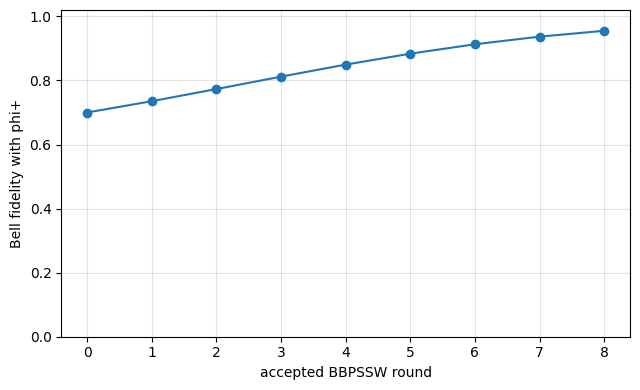

In [220]:
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-simyuj")

try:
    from matplotlib import pyplot as plt

    rounds = [0] + [int(row["round"]) for row in multi_round_trajectory]
    fidelities = [INITIAL_PAIR_FIDELITY] + [float(row["output_fidelity"]) for row in multi_round_trajectory]

    fig, ax = plt.subplots(figsize=(6.5, 4.0))
    ax.plot(rounds, fidelities, marker="o")
    ax.set_xlabel("accepted BBPSSW round")
    ax.set_ylabel("Bell fidelity with phi+")
    ax.set_ylim(0.0, 1.02)
    ax.grid(True, alpha=0.35)
    fig.tight_layout()

    if "agg" in plt.get_backend().lower():
        plot_path = "/tmp/bbpssw_repeated_rounds.png"
        fig.savefig(plot_path, dpi=150, bbox_inches="tight")
        print("saved plot:", plot_path)
    else:
        plt.show()
except Exception as exc:
    print("Plot skipped:", exc)


## Initial fidelity sweep

This sweep runs one accepted BBPSSW round for initial Werner-pair fidelities from `0` to `1`. The plot shows the accepted-round output fidelity against the input fidelity; the dashed diagonal marks no improvement.


In [208]:
FIDELITY_SWEEP_POINTS = 41
FIDELITY_SWEEP_SEED_START = 12000
FIDELITY_SWEEP_MAX_ATTEMPTS = 100

initial_fidelity_grid = [
    index / (FIDELITY_SWEEP_POINTS - 1)
    for index in range(FIDELITY_SWEEP_POINTS)
]


def run_initial_fidelity_sweep(
    fidelities: list[float],
    *,
    base_config: BBPSSWConfig = BBPSSWConfig(),
    seed_start: int = FIDELITY_SWEEP_SEED_START,
    max_attempts_per_fidelity: int = FIDELITY_SWEEP_MAX_ATTEMPTS,
) -> list[dict[str, object]]:
    rows = []
    for index, initial_fidelity in enumerate(fidelities):
        sweep_config = dataclass_replace(
            base_config,
            master_seed=seed_start + index * max_attempts_per_fidelity,
            source_pair_fidelity=initial_fidelity,
            attenuation_db_per_km=0.0,
            channel_depolarizing_probability=0.0,
            memory_depolar_rate=0.0,
        )
        attempt_rows = run_bbpssw_accepted_rounds(
            num_rounds=1,
            initial_fidelity=initial_fidelity,
            base_config=sweep_config,
            seed_start=sweep_config.master_seed,
            max_attempts_per_round=max_attempts_per_fidelity,
        )
        accepted = accepted_trajectory(attempt_rows)
        output_fidelity = accepted[0]["output_fidelity"] if accepted else None
        rows.append(
            {
                "initial_fidelity": initial_fidelity,
                "output_fidelity": output_fidelity,
                "accepted": bool(accepted),
                "attempts": len(attempt_rows),
            }
        )
    return rows


fidelity_sweep_rows = run_initial_fidelity_sweep(initial_fidelity_grid)

print("initial fidelity   output fidelity  attempts")
preview_rows = fidelity_sweep_rows[::5]
if preview_rows[-1] is not fidelity_sweep_rows[-1]:
    preview_rows = preview_rows + fidelity_sweep_rows[-1:]

for row in preview_rows:
    output = row["output_fidelity"]
    output_text = "None" if output is None else f"{float(output):.9f}"
    print(
        f"{float(row['initial_fidelity']):16.3f} "
        f"{output_text:17} "
        f"{int(row['attempts']):9d}"
    )

missing_outputs = [row for row in fidelity_sweep_rows if row["output_fidelity"] is None]
print("missing outputs:", len(missing_outputs))


initial fidelity   output fidelity  attempts
           0.000 0.200000000               1
           0.125 0.195945946               4
           0.250 0.250000000               2
           0.375 0.358108108               1
           0.500 0.500000000               1
           0.625 0.650000000               1
           0.750 0.788461538               2
           0.875 0.905737705               1
           1.000 1.000000000               1
missing outputs: 0


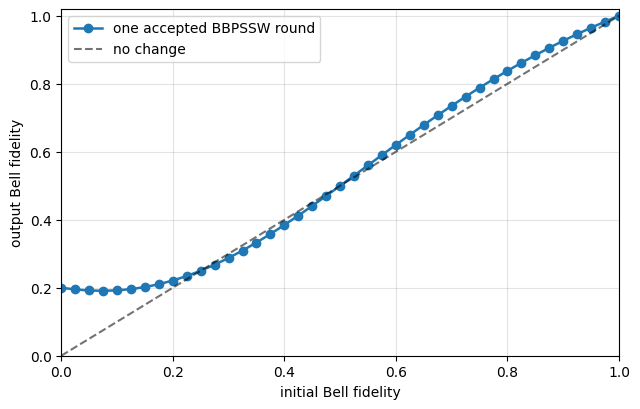

In [209]:
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-simyuj")

try:
    from matplotlib import pyplot as plt

    sweep_x = [float(row["initial_fidelity"]) for row in fidelity_sweep_rows if row["output_fidelity"] is not None]
    sweep_y = [float(row["output_fidelity"]) for row in fidelity_sweep_rows if row["output_fidelity"] is not None]

    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.plot(sweep_x, sweep_y, marker="o", linewidth=1.8, label="one accepted BBPSSW round")
    ax.plot([0.0, 1.0], [0.0, 1.0], linestyle="--", color="black", alpha=0.55, label="no change")
    ax.set_xlabel("initial Bell fidelity")
    ax.set_ylabel("output Bell fidelity")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.02)
    ax.grid(True, alpha=0.35)
    ax.legend()
    fig.tight_layout()

    if "agg" in plt.get_backend().lower():
        plot_path = "/tmp/bbpssw_initial_vs_output_fidelity.png"
        fig.savefig(plot_path, dpi=150, bbox_inches="tight")
        print("saved plot:", plot_path)
    else:
        plt.show()
except Exception as exc:
    print("Plot skipped:", exc)


## One-round success and gain sweep

This sweep runs many independent one-round BBPSSW trials at each input fidelity. It records the conditional output fidelity of accepted rounds, the empirical success probability, and the fidelity gain.

In [210]:
SUCCESS_SWEEP_POINTS = 41
SUCCESS_SWEEP_TRIALS_PER_FIDELITY = 200
SUCCESS_SWEEP_SEED_START = 22000

success_sweep_fidelities = [
    index / (SUCCESS_SWEEP_POINTS - 1)
    for index in range(SUCCESS_SWEEP_POINTS)
]


def run_bbpssw_success_sweep(
    fidelities: list[float],
    *,
    base_config: BBPSSWConfig = BBPSSWConfig(),
    seed_start: int = SUCCESS_SWEEP_SEED_START,
    trials_per_fidelity: int = SUCCESS_SWEEP_TRIALS_PER_FIDELITY,
) -> list[dict[str, object]]:
    if trials_per_fidelity <= 0:
        raise ValueError("trials_per_fidelity must be positive")

    rows = []
    for fidelity_index, initial_fidelity in enumerate(fidelities):
        accepted_count = 0
        output_sum = 0.0
        output_min = None
        output_max = None

        for trial_index in range(trials_per_fidelity):
            trial_seed = seed_start + fidelity_index * trials_per_fidelity + trial_index
            trial_config = dataclass_replace(
                base_config,
                master_seed=trial_seed,
                source_pair_fidelity=clamp_probability(initial_fidelity),
                attenuation_db_per_km=0.0,
                channel_depolarizing_probability=0.0,
                memory_depolar_rate=0.0,
            )

            session = run_bbpssw_scenario(trial_config)
            summary = summarize_session(session)

            if summary["keep"] is not True or summary["final_fidelity"] is None:
                continue

            output_fidelity = float(summary["final_fidelity"])
            accepted_count += 1
            output_sum += output_fidelity
            output_min = output_fidelity if output_min is None else min(output_min, output_fidelity)
            output_max = output_fidelity if output_max is None else max(output_max, output_fidelity)

        success_probability = accepted_count / trials_per_fidelity
        mean_output_fidelity = output_sum / accepted_count if accepted_count else None
        fidelity_gain = (
            None
            if mean_output_fidelity is None
            else mean_output_fidelity - float(initial_fidelity)
        )
        pairs_per_accepted = None if success_probability == 0.0 else 2.0 / success_probability

        rows.append(
            {
                "initial_fidelity": float(initial_fidelity),
                "output_fidelity": mean_output_fidelity,
                "fidelity_gain": fidelity_gain,
                "success_probability": success_probability,
                "accepted": accepted_count,
                "trials": trials_per_fidelity,
                "pairs_per_accepted": pairs_per_accepted,
                "output_min": output_min,
                "output_max": output_max,
            }
        )

    return rows


bbpssw_success_sweep_rows = run_bbpssw_success_sweep(success_sweep_fidelities)

print("initial fidelity   output fidelity          gain   P_success   accepted/trials   pairs/accepted")
preview_stride = max(1, len(bbpssw_success_sweep_rows) // 10)
preview_rows = bbpssw_success_sweep_rows[::preview_stride]
if preview_rows[-1] is not bbpssw_success_sweep_rows[-1]:
    preview_rows = preview_rows + bbpssw_success_sweep_rows[-1:]

for row in preview_rows:
    output = row["output_fidelity"]
    gain = row["fidelity_gain"]
    pairs = row["pairs_per_accepted"]
    output_text = "None" if output is None else f"{float(output):.9f}"
    gain_text = "None" if gain is None else f"{float(gain): .9f}"
    pairs_text = "None" if pairs is None else f"{float(pairs):.2f}"
    print(
        f"{float(row['initial_fidelity']):16.3f} "
        f"{output_text:17} "
        f"{gain_text:13} "
        f"{float(row['success_probability']):11.3f} "
        f"{int(row['accepted']):8d}/{int(row['trials']):<6d} "
        f"{pairs_text:>14}"
    )


initial fidelity   output fidelity          gain   P_success   accepted/trials   pairs/accepted
           0.000 0.200000000        0.200000000        0.515      103/200              3.88
           0.100 0.192307692        0.092307692        0.505      101/200              3.96
           0.200 0.221238938        0.021238938        0.430       86/200              4.65
           0.300 0.287610619       -0.012389381        0.550      110/200              3.64
           0.400 0.384615385       -0.015384615        0.475       95/200              4.21
           0.500 0.500000000       -0.000000000        0.490       98/200              4.08
           0.600 0.620437956        0.020437956        0.645      129/200              3.10
           0.700 0.735294118        0.035294118        0.675      135/200              2.96
           0.800 0.838150289        0.038150289        0.760      152/200              2.63
           0.900 0.926395939        0.026395939        0.885      177/200   

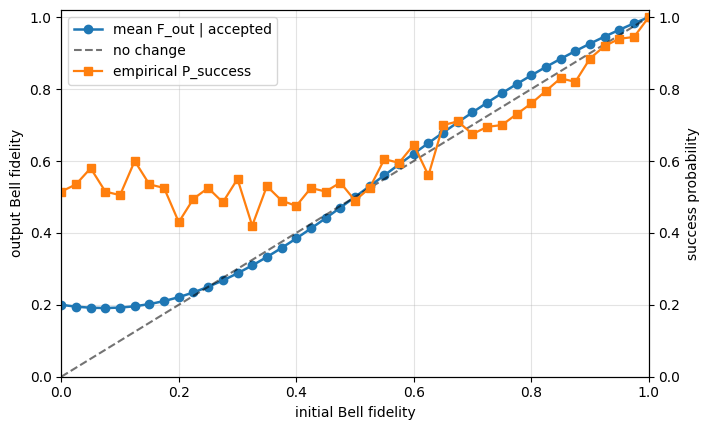

In [211]:
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-simyuj")

try:
    from matplotlib import pyplot as plt

    plot_rows = [row for row in bbpssw_success_sweep_rows if row["output_fidelity"] is not None]
    sweep_x = [float(row["initial_fidelity"]) for row in plot_rows]
    sweep_y = [float(row["output_fidelity"]) for row in plot_rows]
    success_y = [float(row["success_probability"]) for row in plot_rows]

    fig, fidelity_ax = plt.subplots(figsize=(7.2, 4.4))
    fidelity_ax.plot(
        sweep_x,
        sweep_y,
        marker="o",
        linewidth=1.8,
        label="mean F_out | accepted",
    )
    fidelity_ax.plot(
        [0.0, 1.0],
        [0.0, 1.0],
        linestyle="--",
        color="black",
        alpha=0.55,
        label="no change",
    )
    fidelity_ax.set_xlabel("initial Bell fidelity")
    fidelity_ax.set_ylabel("output Bell fidelity")
    fidelity_ax.set_xlim(0.0, 1.0)
    fidelity_ax.set_ylim(0.0, 1.02)
    fidelity_ax.grid(True, alpha=0.35)

    success_ax = fidelity_ax.twinx()
    success_ax.plot(
        sweep_x,
        success_y,
        marker="s",
        linewidth=1.6,
        color="tab:orange",
        label="empirical P_success",
    )
    success_ax.set_ylabel("success probability")
    success_ax.set_ylim(0.0, 1.02)

    lines = fidelity_ax.get_lines() + success_ax.get_lines()
    labels = [line.get_label() for line in lines]
    fidelity_ax.legend(lines, labels, loc="best")
    fig.tight_layout()

    if "agg" in plt.get_backend().lower():
        plot_path = "/tmp/bbpssw_fout_and_success_probability.png"
        fig.savefig(plot_path, dpi=150, bbox_inches="tight")
        print("saved plot:", plot_path)
    else:
        plt.show()
except Exception as exc:
    print("Plot skipped:", exc)


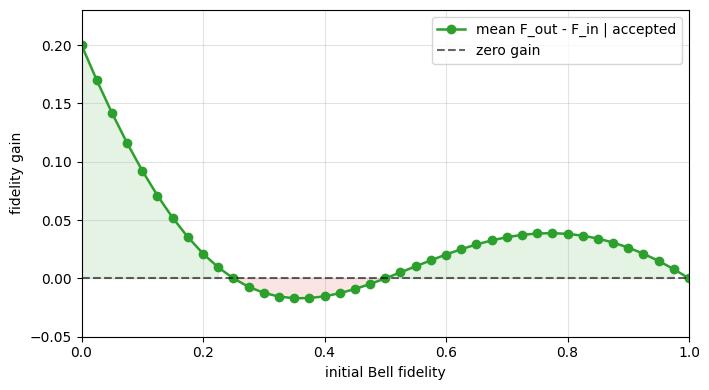

In [212]:
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-simyuj")

try:
    from matplotlib import pyplot as plt

    gain_rows = [row for row in bbpssw_success_sweep_rows if row["fidelity_gain"] is not None]
    sweep_x = [float(row["initial_fidelity"]) for row in gain_rows]
    gain_y = [float(row["fidelity_gain"]) for row in gain_rows]
    positive_gain = [gain >= 0.0 for gain in gain_y]
    negative_gain = [gain < 0.0 for gain in gain_y]

    fig, ax = plt.subplots(figsize=(7.2, 4.0))
    ax.plot(
        sweep_x,
        gain_y,
        marker="o",
        linewidth=1.8,
        color="tab:green",
        label="mean F_out - F_in | accepted",
    )
    ax.axhline(0.0, linestyle="--", color="black", alpha=0.6, label="zero gain")
    ax.fill_between(sweep_x, 0.0, gain_y, where=positive_gain, color="tab:green", alpha=0.12)
    ax.fill_between(sweep_x, 0.0, gain_y, where=negative_gain, color="tab:red", alpha=0.12)
    ax.set_xlabel("initial Bell fidelity")
    ax.set_ylabel("fidelity gain")
    ax.set_xlim(0.0, 1.0)
    lower = min(-0.05, min(gain_y) - 0.03)
    upper = max(0.05, max(gain_y) + 0.03)
    ax.set_ylim(lower, upper)
    ax.grid(True, alpha=0.35)
    ax.legend(loc="best")
    fig.tight_layout()

    if "agg" in plt.get_backend().lower():
        plot_path = "/tmp/bbpssw_fidelity_gain.png"
        fig.savefig(plot_path, dpi=150, bbox_inches="tight")
        print("saved plot:", plot_path)
    else:
        plt.show()
except Exception as exc:
    print("Plot skipped:", exc)
